# Cross Validation

Nesta tarefa, você trabalhará com uma base de dados que contém informações sobre variáveis ambientais coletadas para a detecção de incêndios. O objetivo é utilizar técnicas de validação cruzada (cross-validation) para avaliar a performance de um modelo de classificação na previsão da ocorrência de um incêndio com base nas variáveis fornecidas.


Descrição da Base de Dados
A base de dados contém as seguintes variáveis:

Unnamed:0: Índice (não é uma variável útil para o modelo)

UTC: Tempo em Segundos UTC

Temperature[C]: Temperatura do Ar (em graus Celsius)

Humidity[%]: Umidade do Ar (em porcentagem)

TVOC[ppb]: Total de Compostos Orgânicos Voláteis (medido em partes por bilhão)

eCO2[ppm]: Concentração equivalente de CO2 (medido em partes por milhão)

Raw H2: Hidrogênio molecular bruto, não compensado

Raw Ethanol: Etanol gasoso bruto

Pressure[hPA]: Pressão do Ar (em hectopascais)

PM1.0: Material particulado de tamanho < 1,0 µm

PM2.5: Material particulado de tamanho >1,0 µm e < 2,5 µm

NC0.5: Concentração numérica de material particulado de tamanho < 0,5 µm

NC1.0: Concentração numérica de material particulado de tamanho 0,5 µm < 1,0 µm

NC2.5: Concentração numérica de material particulado de tamanho 1,0 µm < 2,5 µm

CNT: Contador de amostras


E a variável alvo:

Fire Alarm: Indicador binário de incêndio (1 se houver incêndio, 0 caso contrário)

O objetivo desta tarefa é aplicar a técnica de validação cruzada (cross-validation) para avaliar a performance de um modelo de classificação. A validação cruzada ajudará a garantir que o modelo seja avaliado de maneira robusta e generalize bem para dados não vistos.

In [15]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


# Exploração inicial dos dos dados

In [49]:
df = pd.read_csv('smoke_detection_iot.csv')
print(df.head(2))
print(df.columns)

   Unnamed: 0         UTC  Temperature[C]  Humidity[%]  TVOC[ppb]  eCO2[ppm]  \
0           0  1654733331          20.000        57.36          0        400   
1           1  1654733332          20.015        56.67          0        400   

   Raw H2  Raw Ethanol  Pressure[hPa]  PM1.0  PM2.5  NC0.5  NC1.0  NC2.5  CNT  \
0   12306        18520        939.735    0.0    0.0    0.0    0.0    0.0    0   
1   12345        18651        939.744    0.0    0.0    0.0    0.0    0.0    1   

   Fire Alarm  
0           0  
1           0  
Index(['Unnamed: 0', 'UTC', 'Temperature[C]', 'Humidity[%]', 'TVOC[ppb]',
       'eCO2[ppm]', 'Raw H2', 'Raw Ethanol', 'Pressure[hPa]', 'PM1.0', 'PM2.5',
       'NC0.5', 'NC1.0', 'NC2.5', 'CNT', 'Fire Alarm'],
      dtype='object')


O Nome da coluna 'Fire Alarm', por ter um espaço no nome, pode causar problemas. Por isso, o nome foi alterado.

In [81]:
df.rename(columns={'Fire Alarm': 'Fire_Alarm'}, inplace=True)
print(df.columns)

Index(['Unnamed: 0', 'UTC', 'Temperature[C]', 'Humidity[%]', 'TVOC[ppb]',
       'eCO2[ppm]', 'Raw H2', 'Raw Ethanol', 'Pressure[hPa]', 'PM1.0', 'PM2.5',
       'NC0.5', 'NC1.0', 'NC2.5', 'CNT', 'Fire_Alarm'],
      dtype='object')


In [51]:
df.isnull().sum()

Unnamed: 0        0
UTC               0
Temperature[C]    0
Humidity[%]       0
TVOC[ppb]         0
eCO2[ppm]         0
Raw H2            0
Raw Ethanol       0
Pressure[hPa]     0
PM1.0             0
PM2.5             0
NC0.5             0
NC1.0             0
NC2.5             0
CNT               0
Fire_Alarm        0
dtype: int64

In [52]:
df.dtypes

Unnamed: 0          int64
UTC                 int64
Temperature[C]    float64
Humidity[%]       float64
TVOC[ppb]           int64
eCO2[ppm]           int64
Raw H2              int64
Raw Ethanol         int64
Pressure[hPa]     float64
PM1.0             float64
PM2.5             float64
NC0.5             float64
NC1.0             float64
NC2.5             float64
CNT                 int64
Fire_Alarm          int64
dtype: object

# Exploração de dados para a escolha do modelo

# 2 - Para essa base, onde você realizará as previsões de fire alarm, qual modelo de machine learning você aplicará? Justifique.




In [53]:
corr['Fire_Alarm'].sort_values(ascending=False)

Fire_Alarm        1.000000
CNT               0.673762
Humidity[%]       0.399846
Pressure[hPa]     0.249797
Raw H2            0.107007
NC2.5            -0.057707
NC1.0            -0.082828
PM2.5            -0.084916
eCO2[ppm]        -0.097006
PM1.0            -0.110552
NC0.5            -0.128118
Temperature[C]   -0.163902
TVOC[ppb]        -0.214743
Raw Ethanol      -0.340652
Unnamed: 0       -0.361351
UTC              -0.389404
Name: Fire_Alarm, dtype: float64

há um grupo bem amrcado, relacionado entre si, possível ver no vermelho. ao mesmo tempo sua relação com fire alarm é muito pequena. já cnt tem o comportamento ao contrário, então é possível que existam grupos. for ver o sns plot

In [82]:
df[['UTC', 'Temperature[C]', 'Humidity[%]', 'eCO2[ppm]', 'PM1.0','CNT', 'Fire_Alarm']]

,UTC,Temperature[C],Humidity[%],eCO2[ppm],PM1.0,CNT,Fire_Alarm
0,1654733331,20.000,57.36,400,0.00,0,0
1,1654733332,20.015,56.67,400,0.00,1,0
2,1654733333,20.029,55.96,400,0.00,2,0
3,1654733334,20.044,55.28,400,0.00,3,0
4,1654733335,20.059,54.69,400,0.00,4,0
...,...,...,...,...,...,...,...
62625,1655130047,18.438,15.79,400,0.63,5739,0
62626,1655130048,18.653,15.87,400,0.61,5740,0
62627,1655130049,18.867,15.84,400,0.57,5741,0
62628,1655130050,19.083,16.04,400,0.57,5742,0


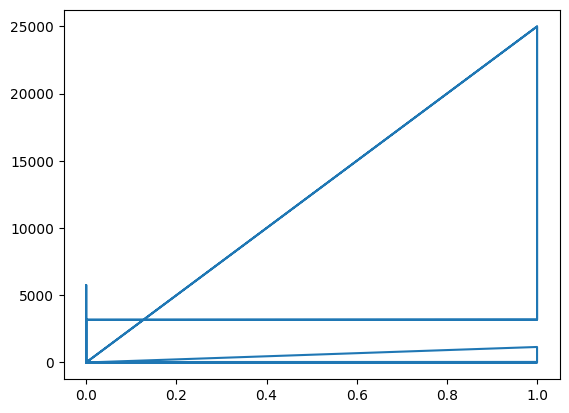

In [71]:
plt.plot(df['Fire_Alarm'], df['CNT'])

In [77]:
df['CNT'].groupby(df['Fire_Alarm']).count()


Fire_Alarm
0    17873
1    44757
Name: CNT, dtype: int64

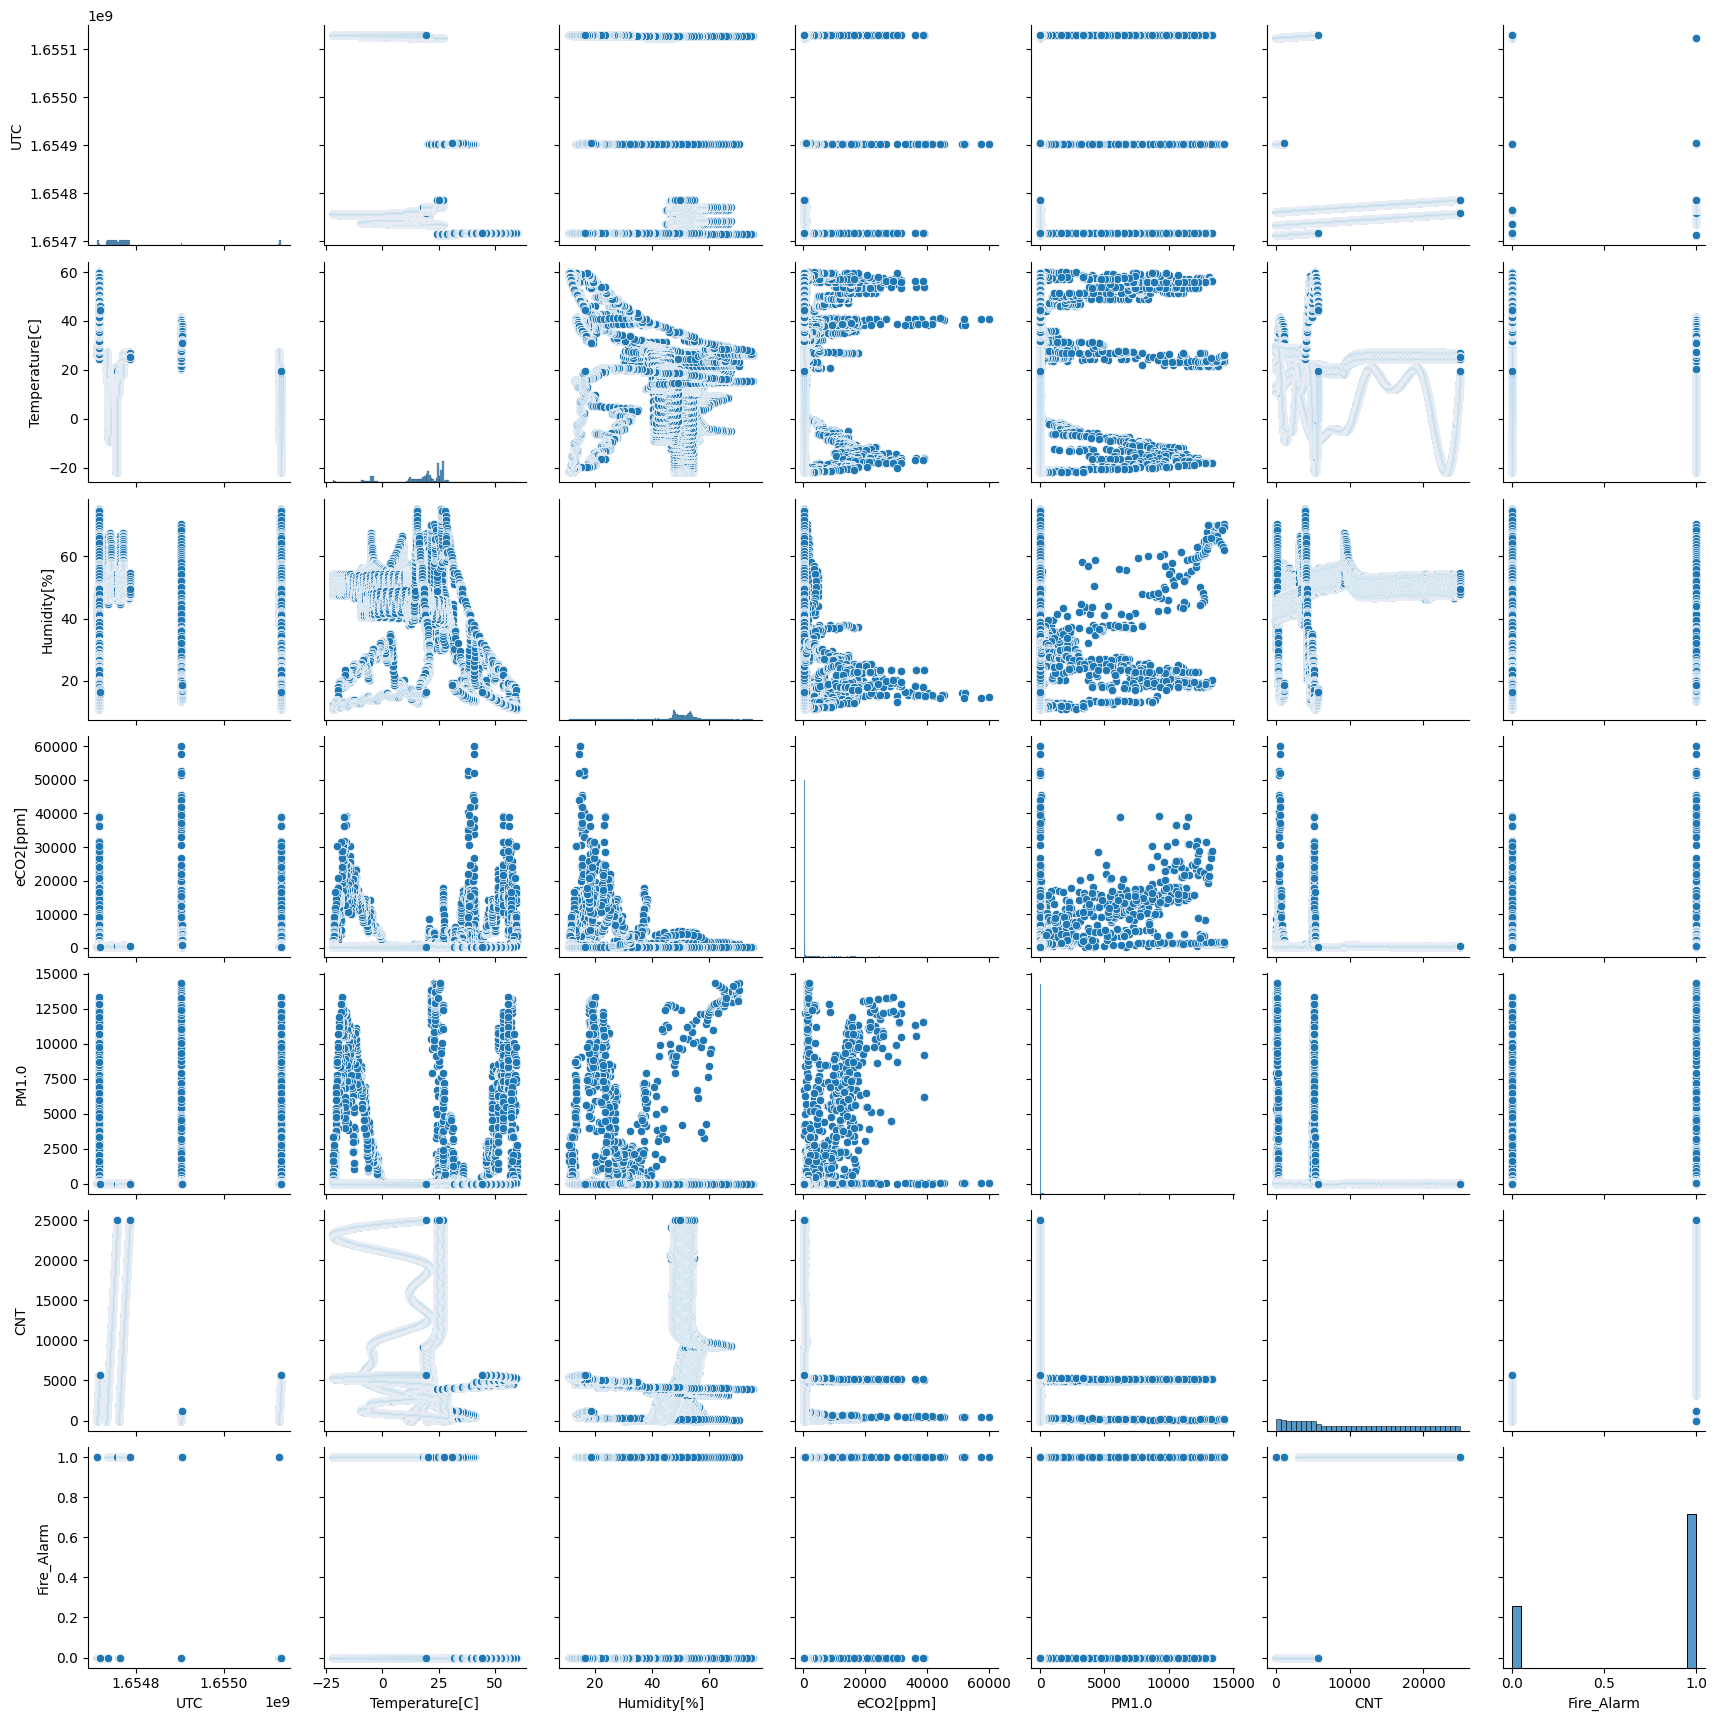

In [85]:
sns.pairplot(df[['UTC', 'Temperature[C]', 'Humidity[%]', 'eCO2[ppm]', 'PM1.0','CNT', 'Fire_Alarm']])
plt.show()

uma regressão linear    cai bem
não faz sentido regressão com variáveç binária.
acho que kmeans faz mais sentido, mas avaliar se foram grupos não é tão fácil. a árvore de decisão pode ser interessante, por que vocÊ vai juntando as condições, mais de uma condição junta.

In [78]:
df.groupby(df['Fire_Alarm']).count()


,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT
Fire_Alarm,,,,,,,,,,,,,,,
0,17873,17873,17873,17873,17873,17873,17873,17873,17873,17873,17873,17873,17873,17873,17873
1,44757,44757,44757,44757,44757,44757,44757,44757,44757,44757,44757,44757,44757,44757,44757


# 3 - Separe a base em Y e X e já rode a instância do modelo que você utilizará.

## Árvore de decisão (depois talvez random forest)

In [67]:
x = df['Fire_Alarm']
y = df['CNT']
print(x.shape, y.shape)


(62630,) (62630,)


# 4 - Defina o número de Folds e rode o modelo com a validação cruzada.

In [69]:
folds = 5
crossvalidation = KFold(n_splits=folds, shuffle=True, random_state=folds)
modelo_final = cross_val_score(modelo, x, y, cv = folds)

/var/data/python/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/var/data/python/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/data/python/lib/python3.13/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/var/data/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py", line 1247, in fit
    X, y = validate_data(
           ~~~~~~~~~~~~~^
        self,
        ^^^^^
    ...<5 lines>...
        accept_large_sparse=solver not in ["liblinear", "sag", "saga"],
  

# 5 - Avalie a pontuação de cada modelo e ao final a validação final da média.

In [16]:
# seu código aqui